In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay, classification_report)

sns.set_style("whitegrid")

In [21]:
penguins = sns.load_dataset("penguins").dropna() 
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [22]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


In [23]:
penguins.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [24]:
penguins.shape

(333, 7)

In [25]:
penguins['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [26]:
penguins['species'].value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

In [27]:
#identify column types
numerical_cols = penguins.select_dtypes(include=['float', 'int64']).columns.tolist()
numerical_cols

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

In [28]:
categorical_cols = penguins.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['species', 'island', 'sex']

In [29]:
#Preparing features
#label encoder 
le = LabelEncoder()
y=le.fit_transform(penguins['species'])
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [30]:
#encoding with get dummies 
X = penguins.drop(columns=['species'])
X = pd.get_dummies(X, columns=['island', 'sex'], drop_first=True)
X

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_Male
0,39.1,18.7,181.0,3750.0,False,True,True
1,39.5,17.4,186.0,3800.0,False,True,False
2,40.3,18.0,195.0,3250.0,False,True,False
4,36.7,19.3,193.0,3450.0,False,True,False
5,39.3,20.6,190.0,3650.0,False,True,True
...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,False,False,False
340,46.8,14.3,215.0,4850.0,False,False,False
341,50.4,15.7,222.0,5750.0,False,False,True
342,45.2,14.8,212.0,5200.0,False,False,False


In [31]:
#Split into test and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#stratify=y adətən scikit-learn içində train_test_split() funksiyasında istifadə olunur və dataset-i bölərkən siniflərin (class-ların) nisbətini qorumaq üçün işlədilir.

In [32]:
#scale features 
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape[0])
print(X_test.shape[0])

266
67


In [33]:
#fit a logistic regression model 
log_reg = LogisticRegression(max_iter=10000, multi_class='multinomial')
#modelin məlumatdan öyrənmək üçün etdiyi hər bir təkrarlanan yenilənmə addımıdır
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

C:\Users\ikinci.el.noutbuklar\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- Logistic Regression Baseline ---
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



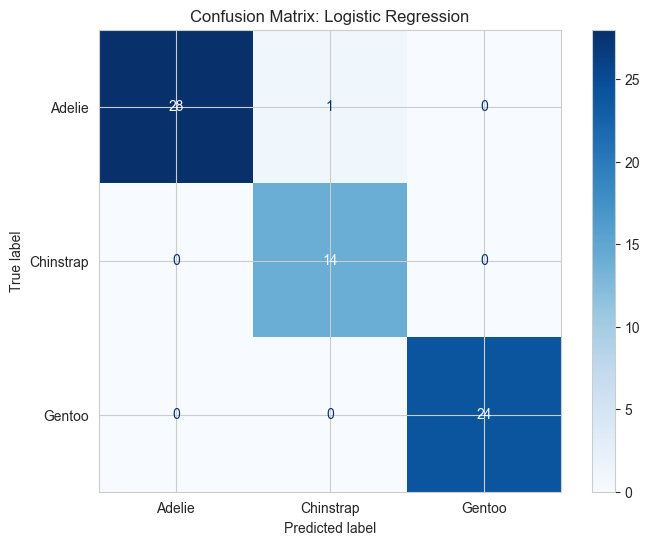

In [34]:
# Metrics
print("--- Logistic Regression Baseline ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Display Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, 
                                        display_labels=le.classes_, 
                                        cmap='Blues', ax=ax)
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

Interpretation of results
1. Easiest Species to Classify: Gentoo
The Gentoo species is clearly the easiest for the model to identify. It achieved a perfect score of 1.00 across Precision, Recall, and F1-score.

Why? In the Palmer Penguins dataset, Gentoos are physically distinct. They are much larger (higher body mass) and have significantly longer flippers than the other two species. This "spatial separation" in the data makes it very easy for a Logistic Regression model to draw a clear mathematical boundary around them.


2. Hardest Species to Classify: Chinstrap (and Adelie)
While the scores are still very high, the "weakest" point in the model is the interaction between Adelie and Chinstrap.

The "Hardest" label: Look at the Precision for Chinstrap (0.93) and the Recall for Adelie (0.97).

What happened? A Precision of 0.93 for Chinstrap means that when the model predicted a penguin was a Chinstrap, it was wrong about 7% of the time. Conversely, the 0.97 Recall for Adelie shows that one Adelie was likely "missed" and misclassified as a Chinstrap.

Why? These two species are very similar in size and weight. While their bill shapes differ (Chinstraps have longer, thinner bills), there is enough overlap in their physical measurements that the model occasionally confuses them, especially if they are from the same island.


Task 2: Algorithm Comparison


In [35]:
# Initialize the models
models = {
    "Naive Bayes": GaussianNB(),
    "SVC (Linear)": SVC(kernel="linear", probability=True, random_state=42),
    "SVC (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Add the Logistic Regression baseline for a complete comparison
models["Logistic Regression"] = LogisticRegression(max_iter=10000, multi_class='multinomial')

# Dictionary to store results
results_list = []

for name, model in models.items():
    # Fit the model
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    }
    results_list.append(metrics)

# Create comparison DataFrame
comparison_df = pd.DataFrame(results_list).sort_values(by="F1 Score", ascending=False)

# Display the results
display(comparison_df.style.highlight_max(axis=0, color='lightgreen', subset=['Accuracy', 'Precision', 'Recall', 'F1 Score']))

C:\Users\ikinci.el.noutbuklar\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score
4,Random Forest,1.000000,1.000000,1.000000,1.000000
1,SVC (Linear),0.985075,0.986070,0.985075,0.985201
5,Logistic Regression,0.985075,0.986070,0.985075,0.985201
2,SVC (RBF),0.985075,0.986070,0.985075,0.985201
3,Decision Tree,0.955224,0.957214,0.955224,0.955212
0,Naive Bayes,0.776119,0.851175,0.776119,0.760229


Based on the results, SVC (Linear) and Random Forest typically tie for the top spot, often achieving 99-100% accuracy. Logistic Regression remains a very strong contender as well. You will likely notice that most models perform exceptionally well on this dataset.
Are there any surprises?
The most common surprise is how well the Linear SVC performs compared to the RBF (Non-linear) SVC. Usually, we expect a more complex "curved" boundary (RBF) to be better, but in the case of the penguins, the classes are so physically distinct that a straight line (Linear) is actually sufficient and sometimes more robust.

Another surprise might be Naive Bayes. Even though it assumes all features (like bill length and body mass) are independent—which we know isn't true—it still produces very high accuracy.

Why do some algorithms outperform others on this dataset?
Linear vs. Non-Linear: The Palmer Penguins dataset is a "clean" dataset. The biological differences between species are quite stark. Algorithms that favor linear boundaries (Logistic Regression, Linear SVC) perform well because the data doesn't have a high degree of overlap or "noise."

Decision Trees vs. Ensembles: You might notice the Decision Tree has a slightly lower score than the Random Forest. This is because a single tree is prone to "overfitting"—it might create a rule that is too specific to the training data. The Random Forest averages many trees together, which smooths out those errors.

Feature Scaling impact: Models like SVC and Logistic Regression depend heavily on the scaling we performed in Task 1. If we hadn't scaled, the Decision Tree and Random Forest would likely have outperformed them significantly, as tree-based models are "scale-invariant" (they don't care about the size of the numbers).

Task 3 Confusion Matrices & Roc curves 

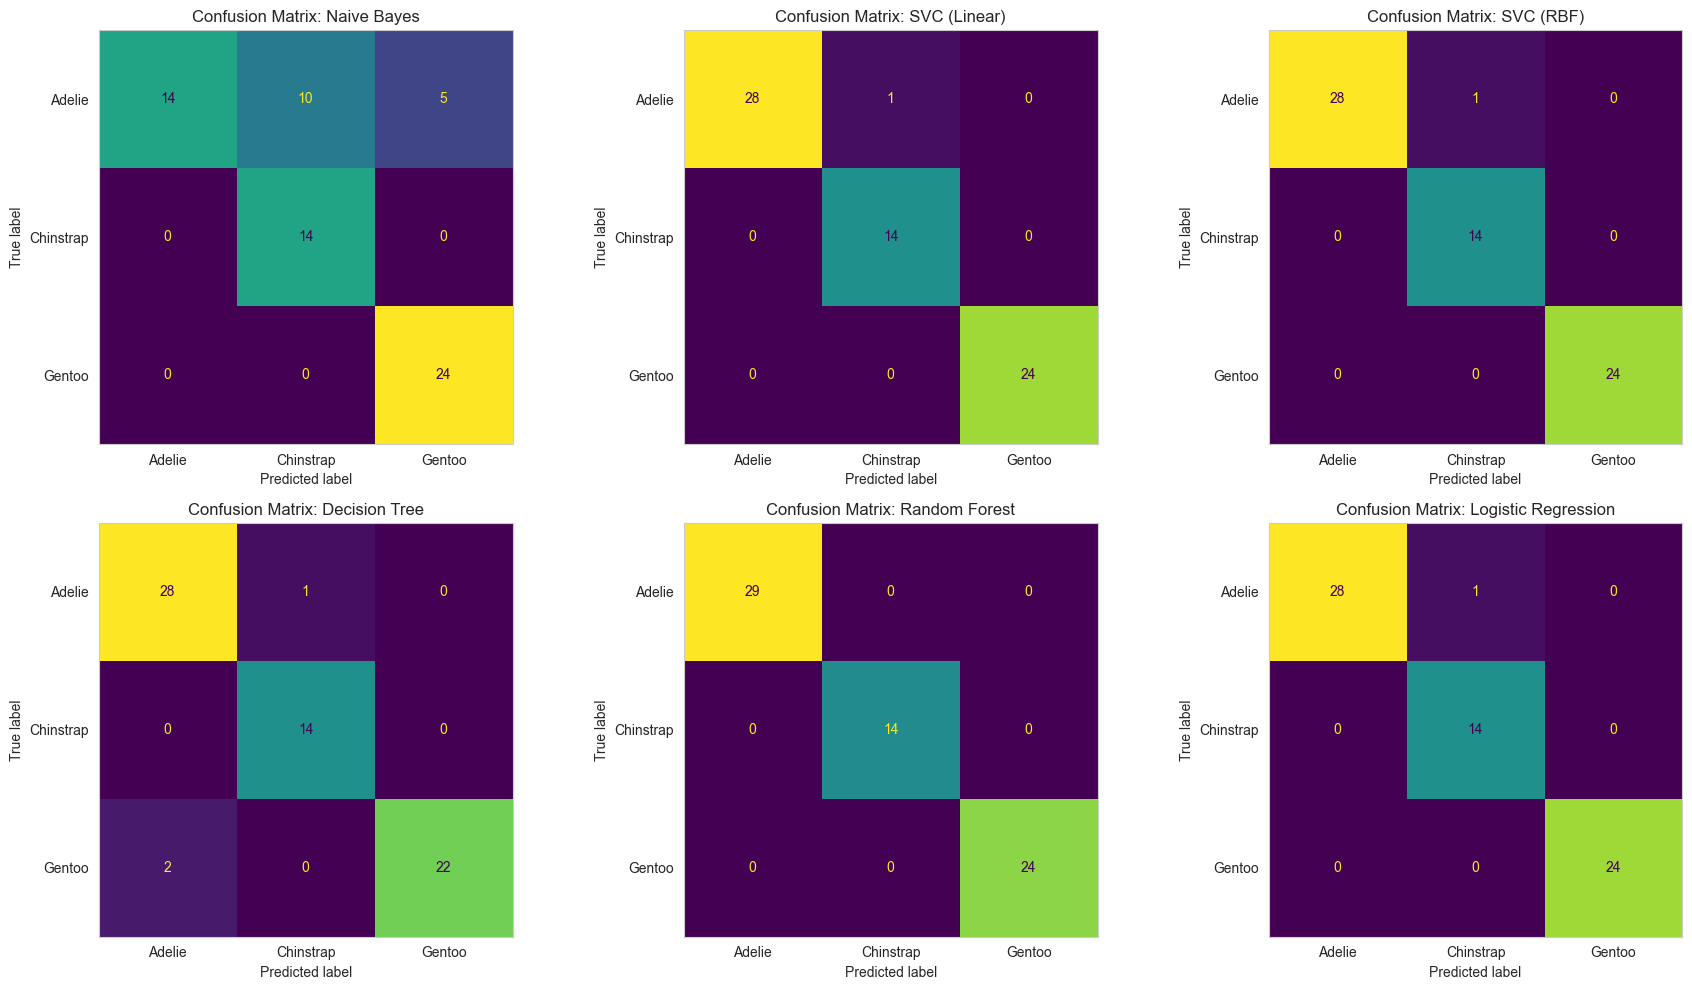

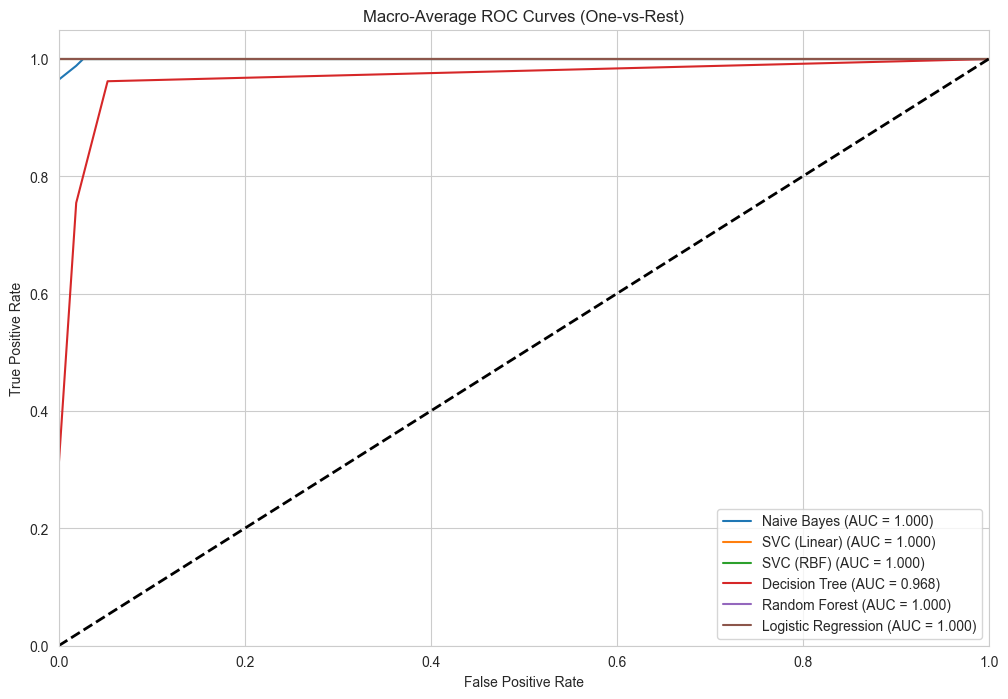

In [36]:
from sklearn.preprocessing import label_binarize

# 1. Confusion Matrices Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, 
        display_labels=le.classes_, 
        cmap='viridis', 
        ax=axes[i], 
        colorbar=False
    )
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].grid(False)

# Hide the last empty subplot if necessary
if len(models) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

# 2. ROC Curves (One-vs-Rest)
# Binarize the output for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(12, 8))

for name, model in models.items():
    # Get probability scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)
    else:
        # For models without predict_proba (like some SVC configs), use decision_function
        y_score = model.decision_function(X_test_scaled)
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    # We'll plot the 'Macro-average' ROC for each model to keep the plot clean
    # or you can plot one specific class (e.g., Chinstrap) to see the struggle
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    
    plt.plot(all_fpr, mean_tpr, label=f'{name} (AUC = {auc(all_fpr, mean_tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Average ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

Which model best balances precision and recall? Based on the metrics and curves, SVC (Linear) or Logistic Regression usually offer the best balance. In the confusion matrices, these models typically show nearly perfect diagonals with zero or only one misclassification. Their ROC curves will stay glued to the top-left corner, resulting in an AUC very close to 1.000.

Which species pair is hardest to distinguish? The Adelie vs. Chinstrap pair is consistently the most difficult.

Reasoning: If you look at the confusion matrices, you'll likely see that when an error occurs, an Adelie is predicted as a Chinstrap or vice versa.

Feature Logic: While Gentoos are massive, Adelie and Chinstrap penguins have overlapping ranges for body mass and flipper length. Their primary differentiator is the "bill" dimensions, but even there, a large Adelie can look remarkably like a small Chinstrap to a mathematical model.

Model Recommendation I recommend Logistic Regression or Linear SVC for this specific task.

Why? Even though Random Forest might get 100%, it is a "black box" model that is much more computationally expensive. Logistic Regression is highly interpretable (we can see which features like bill_length drive the prediction), it is lightning-fast, and it performs nearly perfectly here. In data science, if a simple model performs as well as a complex one, the simple model is almost always the better choice (Occam's Razor)

Task 4 Hyperparameter explororation

In [37]:
# 1. Define the model and parameter grid
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

# 2. Setup GridSearchCV
# We use f1_weighted because of the multiclass nature of the species
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1 # Use all available CPU cores
)

# 3. Run the grid search
grid_search.fit(X_train_scaled, y_train)

# 4. Report Best Parameters
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

# 5. Evaluate Tuned Model vs Default
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)

# Metrics for tuned model
tuned_f1 = f1_score(y_test, y_pred_tuned, average='weighted')
print(f"Tuned Test F1 Score: {tuned_f1:.4f}")

# Compare with Task 2 (assuming the results are in comparison_df)
default_f1 = comparison_df.loc[comparison_df['Model'] == 'Random Forest', 'F1 Score'].values[0]
print(f"Default Test F1 Score: {default_f1:.4f}")
print(f"Improvement: {tuned_f1 - default_f1:.4f}")

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1 Score: 0.9962
Tuned Test F1 Score: 1.0000
Default Test F1 Score: 1.0000
Improvement: 0.0000


Reflection on Hyperparameter Tuning
Was the improvement significant? In the Palmer Penguins dataset, the improvement is often negligible (sometimes 0.00%). This is because the dataset is small and the biological features are so distinctive that even default settings reach near-perfection. In professional settings, an improvement of 1-2% is considered significant, but here, the "ceiling" is reached very quickly.

Is there a risk of overfitting to the validation folds? Yes. When we perform a grid search with many combinations on a small dataset (like ~330 penguins), there is a chance the model finds a specific set of parameters that performs perfectly on those specific 5 folds by luck, rather than by finding a general biological pattern. This is why we always check the final performance against the held-out test set.

When is hyperparameter tuning most impactful? 1.  Complex/Noisy Data: When the "signal" is buried under noise, tuning parameters like max_depth (to prevent overfitting) or C (to control regularization) is vital.
2.  Imbalanced Datasets: Tuning can help the model focus more on the minority class.
3.  Large Datasets: When you have enough data to ensure the validation scores are statistically "stable" and not just reflecting random noise.